In [2]:
from google.colab import files
files.upload()

Saving data_clean.csv to data_clean.csv


{'data_clean.csv': b'Date;Close;Open;High;Low;Volume;Variation;return;volatility;lag1;lag2;vol_lag1;vol_lag2;ret_abs;ret_sq;ma5;ma20;std5;std20\r\n2021-01-07;921.52;915.67;924.79;915.67;;0.64;0.006368442862801919;0.011954787649130341;-0.004195757003982409;-0.010213886076833779;;;0.006368442862801919;4.0557064496772694e-05;922.0899999999999;925.3745000000001;0.007625850446263334;0.011954787649130341\r\n2021-01-08;919.6;921.52;924.31;918.9;;-0.21;-0.002085687729224396;0.011970253365584039;0.006368442862801919;-0.004195757003982409;0.011954787649130341;;0.002085687729224396;4.350093303837217e-06;921.0540000000001;925.9795;0.006724267070272121;0.011970253365584039\r\n2021-01-12;923.89;919.6;923.89;916.78;;0.47;0.004654224046879812;0.010474488730567692;-0.002085687729224396;0.006368442862801919;0.011970253365584039;0.011954787649130341;0.004654224046879812;2.1661801478554292e-05;920.04;925.6135;0.0067547537866474465;0.010474488730567692\r\n2021-01-13;919.89;923.89;925.45;918.95;;-0.43;-0.00

In [3]:
import pandas as pd

df = pd.read_csv("data_clean.csv", sep=';')

In [4]:
print(df.shape)
df.head()

(1319, 19)


,Date,Close,Open,High,Low,Volume,Variation,return,volatility,lag1,lag2,vol_lag1,vol_lag2,ret_abs,ret_sq,ma5,ma20,std5,std20
0,2021-01-07,921.52,915.67,924.79,915.67,NaN,0.64,0.006368,0.011955,-0.004196,-0.010214,NaN,NaN,0.006368,0.000041,922.090,925.3745,0.007626,0.011955
1,2021-01-08,919.60,921.52,924.31,918.90,NaN,-0.21,-0.002086,0.011970,0.006368,-0.004196,0.011955,NaN,0.002086,0.000004,921.054,925.9795,0.006724,0.011970
2,2021-01-12,923.89,919.60,923.89,916.78,NaN,0.47,0.004654,0.010474,-0.002086,0.006368,0.011970,0.011955,0.004654,0.000022,920.040,925.6135,0.006755,0.010474
3,2021-01-13,919.89,923.89,925.45,918.95,NaN,-0.43,-0.004339,0.010480,0.004654,-0.002086,0.010474,0.011970,0.004339,0.000019,920.114,925.2355,0.005074,0.010480
4,2021-01-14,926.07,919.89,926.43,919.89,NaN,0.67,0.006696,0.010576,-0.004339,0.004654,0.010480,0.010474,0.006696,0.000045,922.194,925.0285,0.005117,0.010576


In [5]:
import numpy as np

def clean_number(x):
    x = str(x).strip()

    # enlever espaces
    x = x.replace(' ', '')

    # gérer cas type 1.004.92
    if x.count('.') > 1:
        parts = x.split('.')
        x = ''.join(parts[:-1]) + '.' + parts[-1]

    # remplacer virgule
    x = x.replace(',', '.')

    try:
        return float(x)
    except:
        return np.nan

In [6]:
print(df.columns)

Index(['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Variation', 'return',
       'volatility', 'lag1', 'lag2', 'vol_lag1', 'vol_lag2', 'ret_abs',
       'ret_sq', 'ma5', 'ma20', 'std5', 'std20'],
      dtype='object')


In [7]:
df.columns = df.columns.str.strip()

In [8]:
cols = ['Close', 'Open', 'High', 'Low', 'Volume', 'Variation', 'return', 'volatility', 'lag1', 'lag2','vol_lag1','vol_lag2','ret_abs','ret_sq','ma5','ma20','std5','std20']
print(df[cols].head())
print(df[cols].dtypes)

    Close    Open    High     Low  Volume  Variation    return  volatility  \
0  921.52  915.67  924.79  915.67     NaN       0.64  0.006368    0.011955   
1  919.60  921.52  924.31  918.90     NaN      -0.21 -0.002086    0.011970   
2  923.89  919.60  923.89  916.78     NaN       0.47  0.004654    0.010474   
3  919.89  923.89  925.45  918.95     NaN      -0.43 -0.004339    0.010480   
4  926.07  919.89  926.43  919.89     NaN       0.67  0.006696    0.010576   

       lag1      lag2  vol_lag1  vol_lag2   ret_abs    ret_sq      ma5  \
0 -0.004196 -0.010214       NaN       NaN  0.006368  0.000041  922.090   
1  0.006368 -0.004196  0.011955       NaN  0.002086  0.000004  921.054   
2 -0.002086  0.006368  0.011970  0.011955  0.004654  0.000022  920.040   
3  0.004654 -0.002086  0.010474  0.011970  0.004339  0.000019  920.114   
4 -0.004339  0.004654  0.010480  0.010474  0.006696  0.000045  922.194   

       ma20      std5     std20  
0  925.3745  0.007626  0.011955  
1  925.9795  0.006

In [9]:
for col in ['Open', 'High', 'Low', 'Variation']:
    df[col] = df[col].apply(clean_number)

print(df[cols].head())
print(df[cols].dtypes)

    Close    Open    High     Low  Volume  Variation    return  volatility  \
0  921.52  915.67  924.79  915.67     NaN       0.64  0.006368    0.011955   
1  919.60  921.52  924.31  918.90     NaN      -0.21 -0.002086    0.011970   
2  923.89  919.60  923.89  916.78     NaN       0.47  0.004654    0.010474   
3  919.89  923.89  925.45  918.95     NaN      -0.43 -0.004339    0.010480   
4  926.07  919.89  926.43  919.89     NaN       0.67  0.006696    0.010576   

       lag1      lag2  vol_lag1  vol_lag2   ret_abs    ret_sq      ma5  \
0 -0.004196 -0.010214       NaN       NaN  0.006368  0.000041  922.090   
1  0.006368 -0.004196  0.011955       NaN  0.002086  0.000004  921.054   
2 -0.002086  0.006368  0.011970  0.011955  0.004654  0.000022  920.040   
3  0.004654 -0.002086  0.010474  0.011970  0.004339  0.000019  920.114   
4 -0.004339  0.004654  0.010480  0.010474  0.006696  0.000045  922.194   

       ma20      std5     std20  
0  925.3745  0.007626  0.011955  
1  925.9795  0.006

In [10]:
X_data = df[[
    'return',
    'lag1',
    'lag2',
    'ret_abs',
    'ret_sq',
    'ma5',
    'ma20',
    'std5',
    'std20'
]].values

y_data = df[['volatility']].values

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

In [12]:
import numpy as np

def create_sequences(X, y, seq_length=20):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(Xs), np.array(ys)

X, y = create_sequences(X_scaled, y_scaled, seq_length=20)

print(X.shape)
print(y.shape)

(1299, 20, 9)
(1299, 1)


In [13]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train :", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train : (1039, 20, 9) (1039, 1)
Test : (260, 20, 9) (260, 1)


In [14]:
!pip install tensorflow

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(20,9)))
model.add(Dropout(0.2))

model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

In [17]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - loss: 0.0126 - val_loss: 0.0138
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0038 - val_loss: 0.0099
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0029 - val_loss: 0.0084
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0030 - val_loss: 0.0058
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0028 - val_loss: 0.0059
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0026 - val_loss: 0.0068
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0026 - val_loss: 0.0050
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0025 - val_loss: 0.0046
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0027 - val_loss: 0.0049
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0024 - val_loss: 0.0054
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0020 - val_loss: 0.0034
Epoch 12/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/ste

In [18]:
y_pred = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


In [19]:
y_pred_real = scaler_y.inverse_transform(y_pred)
y_test_real = scaler_y.inverse_transform(y_test)

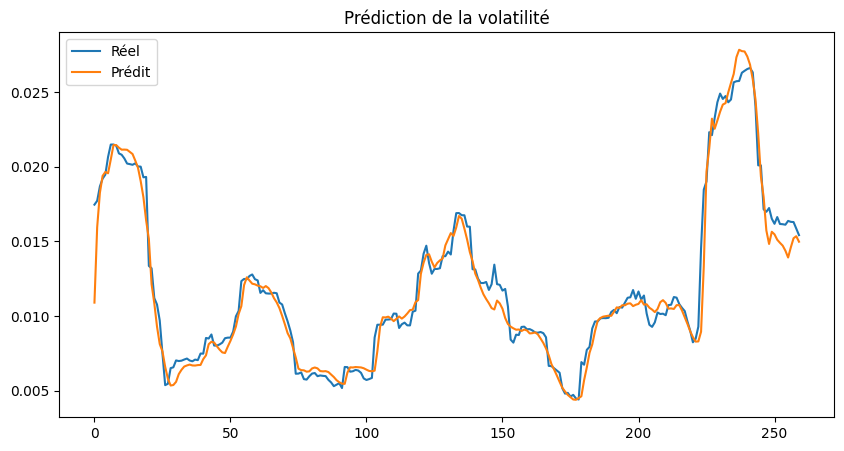

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_real, label="Réel")
plt.plot(y_pred_real, label="Prédit")
plt.legend()
plt.title("Prédiction de la volatilité")
plt.show()

In [21]:
import joblib

joblib.dump(scaler_X, "scaler_X.save")
joblib.dump(scaler_y, "scaler_y.save")

['scaler_y.save']

In [22]:
files.download("scaler_X.save")
files.download("scaler_y.save")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
model.save("model_volatility.h5")

In [24]:
from google.colab import files
files.download("model_volatility.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from google.colab import files
files.download("model_volatility.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)

print("RMSE :", rmse)
print("MAE :", mae)

RMSE : 0.0010506941435350038
MAE : 0.0007131174627553119


In [27]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test_real, y_pred_real)
print("R² :", r2)

R² : 0.9627028419929328
